In [1]:
from tensorflow import keras
from keras.layers import Input, Dense
from keras.models import Model
from keras.datasets import mnist
import numpy as np

In [2]:
import tensorflow as tf

In [3]:
print(tf.__version__)

2.20.0


In [4]:
(x_train, _), (x_test, _) = mnist.load_data()

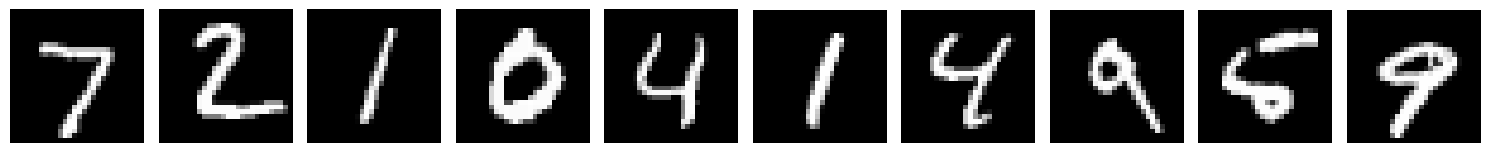

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline

n = 10 # how many digits to display
plt.figure(figsize=(n*1.5, 2))

for i in range(n):
    # display original
    ax = plt.subplot(1, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()

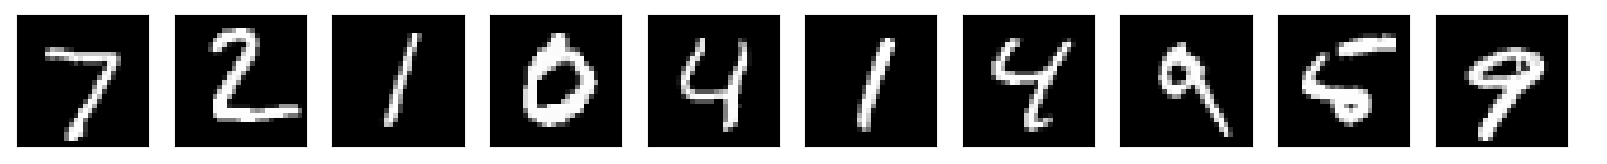

In [6]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, UpSampling2D, Reshape

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense

encode_model = Sequential()

# Encoding
# First block: 28x28x1 -> 14x14x16
encode_model.add(Conv2D(filters=16, kernel_size=(3,3), 
                        input_shape=(28,28,1), 
                        activation='relu', padding='same'))
encode_model.add(MaxPool2D(pool_size=(2,2), padding='same'))

# Second block: 14x14x16 -> 7x7x8
encode_model.add(Conv2D(filters=8, kernel_size=(3,3), 
                        activation='relu', padding='same'))
encode_model.add(MaxPool2D(pool_size=(2,2), padding='same'))

# Bottleneck
encode_model.add(Flatten())
encode_model.add(Dense(30, activation='relu'))  # latent vector size = 30

C:\Users\Madushan Pro\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
############
# Decoding #
############
decode_model=Sequential()

decode_model.add(Dense(7*7*8,activation="relu"))
decode_model.add(Reshape([7,7,8]))

# DeConv1
decode_model.add(Conv2D(filters=8, kernel_size=(3,3), activation='relu', padding='same'))
# Upsampling LAYER
decode_model.add(UpSampling2D((2, 2)))

# Deconv2
decode_model.add(Conv2D(filters=16, kernel_size=(3,3), activation='relu', padding='same'))
# POOLING LAYER
decode_model.add(UpSampling2D((2, 2)))

decode_model.add(Conv2D(1, kernel_size=(3,3), activation='sigmoid', padding='same'))


In [9]:
autoencoder = Sequential([encode_model, decode_model])


In [10]:
autoencoder.compile(optimizer='adadelta', loss='binary_crossentropy', metrics=['accuracy'])


In [11]:
autoencoder.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 30)             │        13,110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 28, 28, 1)      │        14,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,159 (106.09 KB)

 Trainable params: 27,159 (106.09 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
from tensorflow.keras import models

In [13]:
autoencoder.save('Conv_autoencoder.keras')

In [14]:
encode_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 392)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30)             │        11,790 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,110 (51.21 KB)

 Trainable params: 13,110 (51.21 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
decode_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 392)            │        12,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,049 (54.88 KB)

 Trainable params: 14,049 (54.88 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
x_train = x_train.reshape(60000, 28, 28, 1)
x_train = x_train / 255
print(x_train.shape)


(60000, 28, 28, 1)


In [17]:
x_test = x_test.reshape(10000, 28, 28, 1)
x_test = x_test/255
x_test.shape

(10000, 28, 28, 1)

In [18]:
# Train the model
history = autoencoder.fit(
    x=x_train, y=x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    verbose=1,
    validation_data=(x_test, x_test)  # fixed: y_test -> x_test (autoencoder reconstructs its input)
)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.7264 - loss: 0.6907 - val_accuracy: 0.7740 - val_loss: 0.6898
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.7947 - loss: 0.6887 - val_accuracy: 0.8035 - val_loss: 0.6875
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.8075 - loss: 0.6860 - val_accuracy: 0.8070 - val_loss: 0.6843
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.8087 - loss: 0.6822 - val_accuracy: 0.8072 - val_loss: 0.6798
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.8088 - loss: 0.6766 - val_accuracy: 0.8072 - val_loss: 0.6730
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.8088 - loss: 0.6679 - val_accuracy: 0.8072 - val_loss: 0.6621
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.8088 - loss: 0.6534 - val_accuracy: 0.8072 - val_loss: 0.6432
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.8088 - loss: 0.6274 - 

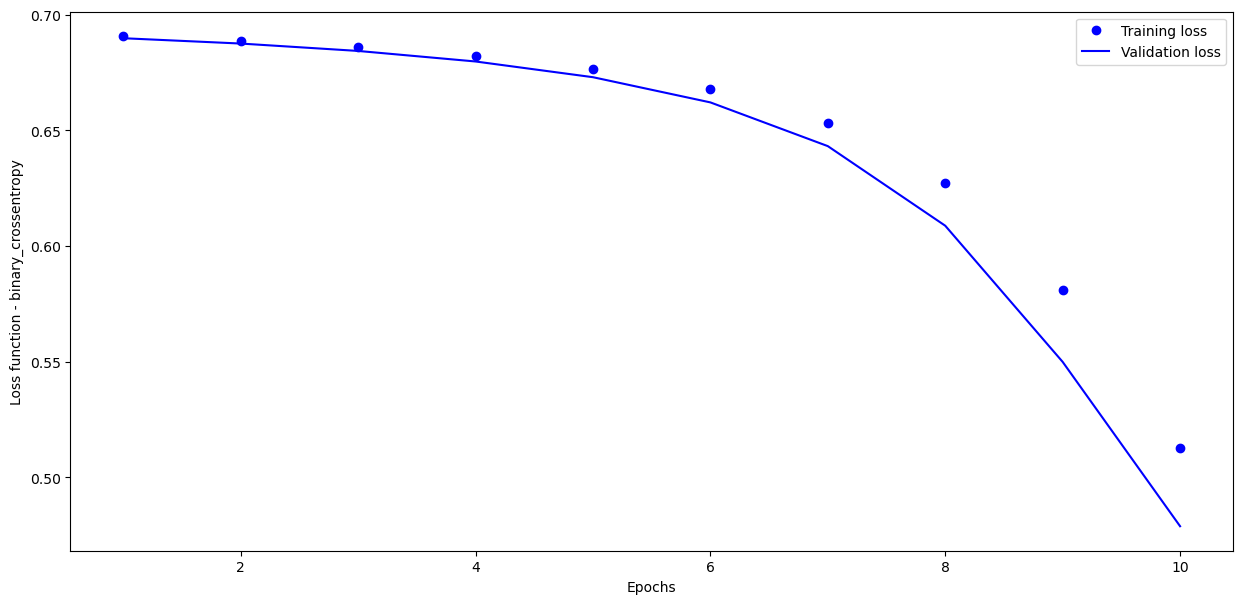

In [19]:
losses = history.history['loss']
losses_val = history.history['val_loss']
epochs = range(1, len(losses) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, losses, 'bo', label='Training loss')
plt.plot(epochs, losses_val, 'b', label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss function - binary_crossentropy')
plt.legend()
plt.show()

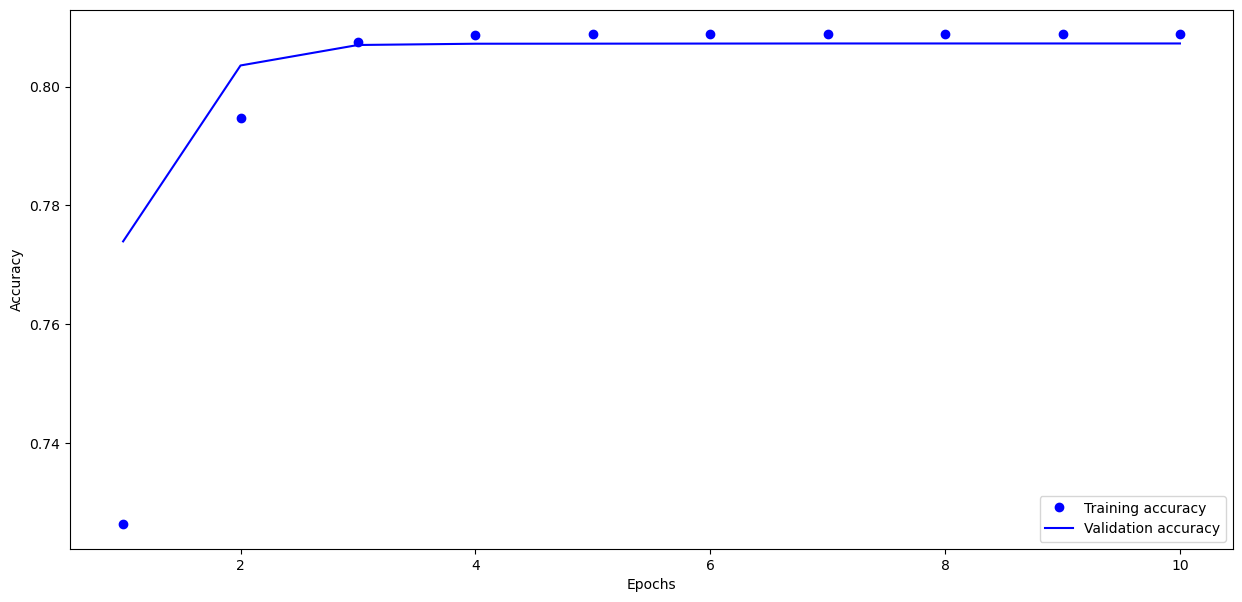

In [20]:
accuracy_array = history.history['accuracy']
val_accuracy_array = history.history['val_accuracy']  # fixed: was history.['val_accuracy']
epochs = range(1, len(accuracy_array) + 1)

plt.figure(num=1, figsize=(15, 7))
plt.plot(epochs, accuracy_array, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy_array, 'b', label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


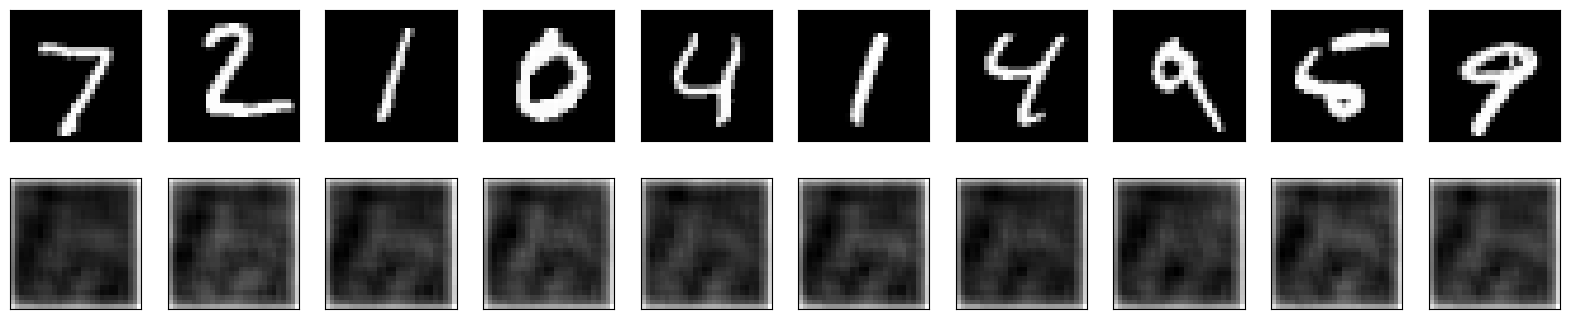

In [21]:
decoded_imgs = autoencoder.predict(x_test)

n = 10

plt.figure(figsize=(20, 4))
for i in range(n):  # fixed: was range() with no argument
    # display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))  # fixed: was reshape(28) - needs 2D shape
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()  # fixed: missing plt.show()


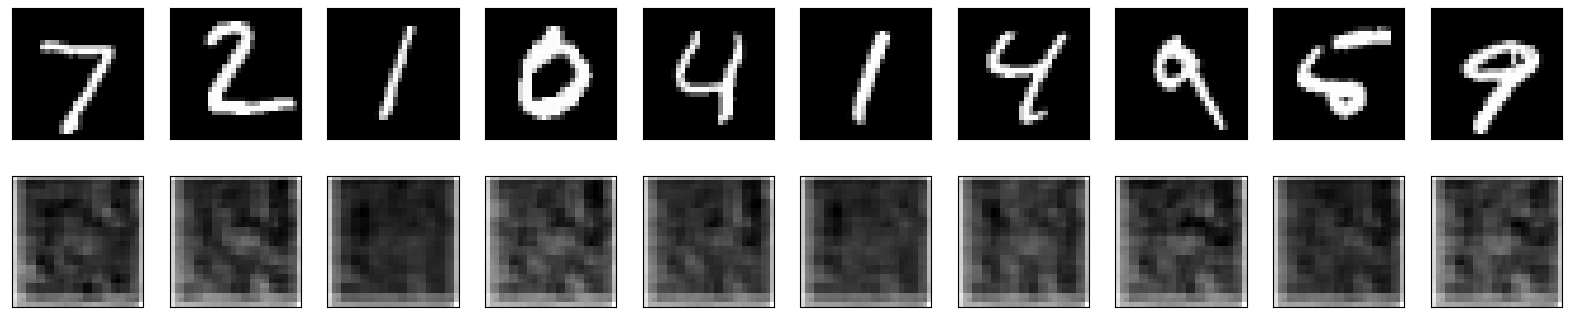

In [22]:
# Lab Logbook: Train autoencoder_2 with epochs = Z + 40

# MY SID :- 2517680 

Z = 0  # Last digit of SID 2517680
lab_epochs = Z + 40
print(f'Training autoencoder_2 for {lab_epochs} epochs')


Training autoencoder_2 for 40 epochs


In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, UpSampling2D, Reshape
from tensorflow.keras import models

# Rebuild the same architecture as Task 2
encode_model_2 = Sequential([
    Conv2D(filters=16, kernel_size=(3,3), input_shape=(28,28,1), activation='relu', padding='same'),
    MaxPool2D(pool_size=(2,2), padding='same'),
    Conv2D(filters=8, kernel_size=(3,3), activation='relu', padding='same'),
    MaxPool2D(pool_size=(2,2), padding='same'),
    Flatten(),
    Dense(30, activation='relu')
])

decode_model_2 = Sequential([
    Dense(7*7*8, activation='relu'),
    Reshape([7, 7, 8]),
    Conv2D(filters=8, kernel_size=(3,3), activation='relu', padding='same'),
    UpSampling2D((2, 2)),
    Conv2D(filters=16, kernel_size=(3,3), activation='relu', padding='same'),
    UpSampling2D((2, 2)),
    Conv2D(1, kernel_size=(3,3), activation='sigmoid', padding='same')
])

autoencoder_2 = Sequential([encode_model_2, decode_model_2])
autoencoder_2.compile(optimizer='adadelta', loss='binary_crossentropy', metrics=['accuracy'])
autoencoder_2.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 30)             │        13,110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 28, 28, 1)      │        14,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,159 (106.09 KB)

 Trainable params: 27,159 (106.09 KB)

 Non-trainable params: 0 (0.00 B)

## Lab Logbook requirement:

1) Copy the autoencoder model and train it with epochs=Z+40,
where your SID is: XXXXXXZ
Leave other parameters the same as in Task 2.

2) Please only add to your Lab Logbook print-screens of:
- Table of your model autoencoder.summary()
- Code of your autoencoder.fit()
- Accuracy detailed graph
- Document the plot of the decoded images for task 2. Change the colour, appearance, and shape of the plot according to your own choice (see plt.figure() parameters).


NOTE: DON'T FORGET TO SAVE AND BACK UP YOUR COMPLETED JUPYTER NOTEBOOK AND LAB LOGBOOK ON GITHUB OR ONEDRIVE.

In [24]:
# Train autoencoder_2 with epochs = Z + 40 (My SID is 2517680) 
history_2 = autoencoder_2.fit(
    x=x_train, y=x_train,
    epochs=40, # Z =0 , Therefore, the number of epochs are 40 
    batch_size=128,
    shuffle=True,
    verbose=1,
    validation_data=(x_test, x_test)
)

Epoch 1/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 45ms/step - accuracy: 0.7853 - loss: 0.6882 - val_accuracy: 0.7958 - val_loss: 0.6870
Epoch 2/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 36s 34ms/step - accuracy: 0.8028 - loss: 0.6855 - val_accuracy: 0.8043 - val_loss: 0.6839
Epoch 3/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.8073 - loss: 0.6818 - val_accuracy: 0.8065 - val_loss: 0.6795
Epoch 4/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.8085 - loss: 0.6766 - val_accuracy: 0.8071 - val_loss: 0.6734
Epoch 5/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.8088 - loss: 0.6691 - val_accuracy: 0.8072 - val_loss: 0.6642
Epoch 6/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.8088 - loss: 0.6575 - val_accuracy: 0.8072 - val_loss: 0.6498
Epoch 7/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.8088 - loss: 0.6383 - val_accuracy: 0.8072 - val_loss: 0.6248
Epoch 8/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.8088 - loss: 0.6036 - 

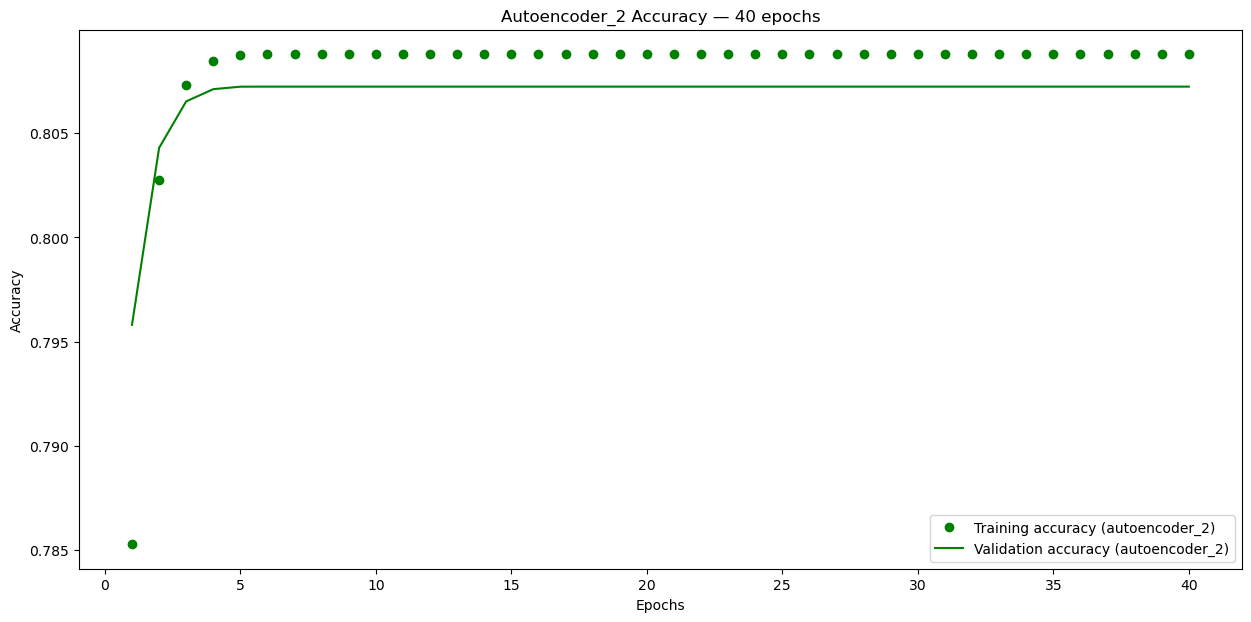

In [25]:
# Accuracy detailed graph for autoencoder_2
accuracy_array_2 = history_2.history['accuracy']
val_accuracy_array_2 = history_2.history['val_accuracy']
epochs_range = range(1, len(accuracy_array_2) + 1)

plt.figure(num=2, figsize=(15, 7))
plt.plot(epochs_range, accuracy_array_2, 'go', label='Training accuracy (autoencoder_2)')
plt.plot(epochs_range, val_accuracy_array_2, 'g', label='Validation accuracy (autoencoder_2)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title(f'Autoencoder_2 Accuracy — {lab_epochs} epochs')
plt.legend()
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


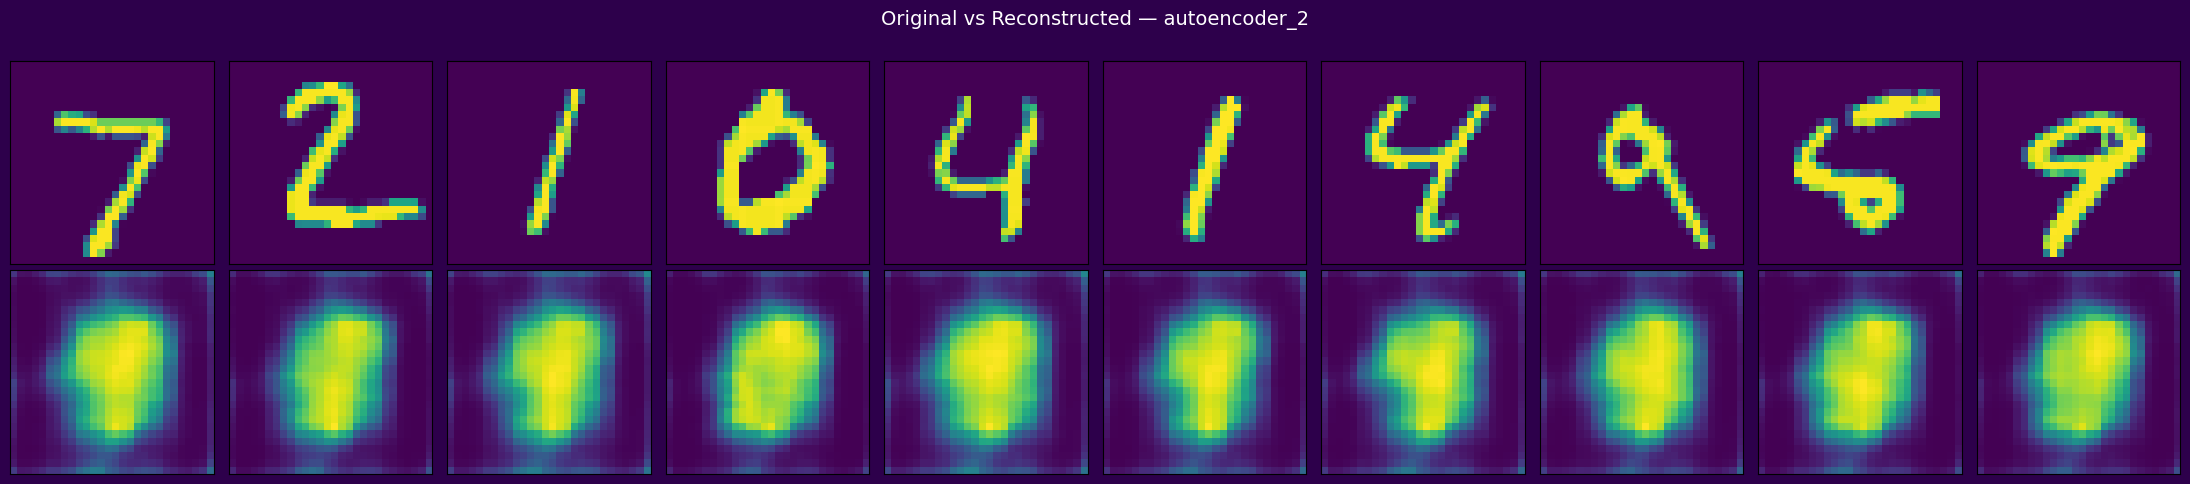

In [26]:
# Decoded images for autoencoder_2 — customised plot (purple background, viridis colormap)
decoded_imgs_2 = autoencoder_2.predict(x_test)

n = 10
fig = plt.figure(figsize=(22, 5), facecolor='#2d004b')  # dark purple background
fig.suptitle('Original vs Reconstructed — autoencoder_2', color='white', fontsize=14)

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='viridis')
    ax.set_facecolor('#2d004b')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_ylabel('Original', color='white', fontsize=9)

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs_2[i].reshape(28, 28), cmap='viridis')
    ax.set_facecolor('#2d004b')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_ylabel('Reconstructed', color='white', fontsize=9)

plt.tight_layout()
plt.show()
